In [1]:
from lib import epl 
from lib import OSN
from lib import readout
from lib import plots
import numpy as np
import pickle 
import brian2 as b2
import brian2hears as b2h
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from playsound import playsound
playsound('harvard_sentence.wav')

ImportError: No module named playsound

In [4]:
cfmin, cfmax, cfN = 50*b2.Hz, 3*b2.kHz, 72 #100 or 72
cf = b2h.erbspace(cfmin, cfmax, cfN)
sound = b2h.loadsound('harvard_sentence.wav')
#sound = sound[slice(13000*ms,40000*ms)]
sound = sound[13000:40000]
gfb = b2h.Gammatone(sound, cf)
ihc = b2h.FunctionFilterbank(gfb, lambda x: 3*clip(x, 0, Inf)**(1.0/3.0))
# Leaky integrate-and-fire model with noise and refractoriness
eqs = '''
dv/dt = (I-v)/(1*ms)+0.2*xi*(2/(1*ms))**.5 : 1 (unless refractory)
I : 1
'''
G = b2h.FilterbankGroup(ihc, 'I', eqs, reset='v=0', threshold='v>1', refractory=5*b2.ms)

Missing compiler_cxx fix for MSVCCompiler


WARNING    Cannot use weave, a test compilation failed: error: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (CompileError) [brian2.codegen.runtime.weave_rt.weave_rt.failed_compile_test]
WARNING    Cannot use Cython, a test compilation failed: Microsoft Visual C++ 9.0 is required. Get it from http://aka.ms/vcpython27 (DistutilsPlatformError) [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]


Text(0.5,1,'Gammatone Filterbank Frequency Over Time')

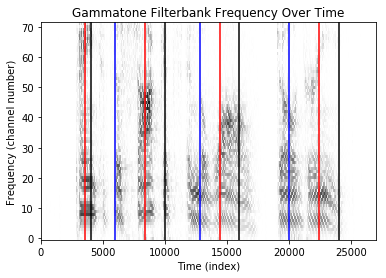

In [5]:
X = np.abs(gfb.process().T)
X = np.log(X+.01)
X += X.min()
plt.imshow(X,aspect='auto', origin='lower left')

xcoords = np.array([440,500,750,1050,1250, 1600,1800,2000,2500,2800,3000])*8
colors = ['r','k','b','r','k','b','r','k','b','r','k']
for xc,c in zip(xcoords,colors):
    plt.axvline(x=xc, label='line at x = {}'.format(xc), c=c)


plt.set_cmap('gray_r')
plt.ylabel('Frequency (channel number)')
plt.xlabel('Time (index)')
plt.title("Gammatone Filterbank Frequency Over Time", loc = 'center')


In [6]:
from lib import epl 
scale = 10
#scale = 33.6
trainingOdors = X[:,xcoords[0]].T/X.max()*scale
trainingOdors = [trainingOdors.astype(np.int64)]

testOdors = X[:,xcoords[1:]].T/X.max()*scale
testOdors = testOdors.astype(np.int64)


nOdors = len(trainingOdors); 
nTestPerOdor = len(testOdors)/nOdors;  
print("Number of odors to train = " + str(len(trainingOdors))); 
print("Number of odors to test = " + str(len(testOdors))); 

#Network initialization
nMCs = len(trainingOdors[0]); 
GCsPerNeurogenesis = 5; 
nGCs = nMCs*GCsPerNeurogenesis*nOdors;     #every MC has 5 GCs per odor  
epl = epl.EPL(nMCs, nGCs, GCsPerNeurogenesis); 

#Sniff
def sniff(odor, learn_flag=0, nGammaPerOdor=5, gPeriod=40):
    sensorInput = OSN.OSN_encoding(odor); 
    for j in range(0, nGammaPerOdor):
        for k in range(0, gPeriod): 
            epl.update(sensorInput, learn_flag=learn_flag);
            pass; 
    epl.reset(); 

#Training
for i in range(0, len(trainingOdors)):
    print("Training odor " + str(i+1)) 
    sniff(trainingOdors[i], learn_flag=1, nGammaPerOdor = 5);
    epl.GClayer.invokeNeurogenesis();
    sniff(trainingOdors[i], learn_flag=0);

#Testing
for i in range(0, len(testOdors)):
    sniff(testOdors[i], learn_flag=0); 
    if(i==len(testOdors)-1):
        print(str(i+1) + " odors tested"); 

#Readout
sMatrix = readout.readout(epl.gammaCode, nOdors, nTestPerOdor)  





Number of odors to train = 1
Number of odors to test = 10
Training odor 1
10 odors tested


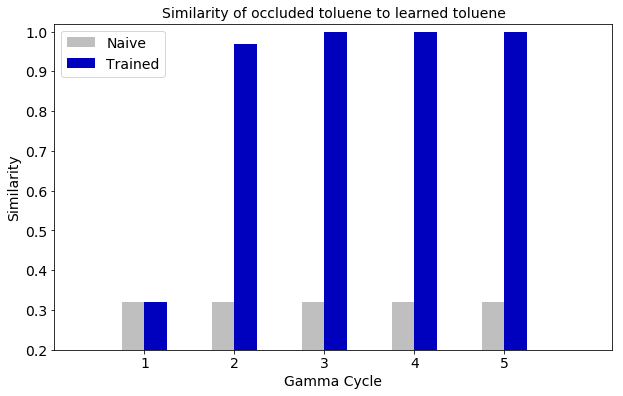

(0, 1)

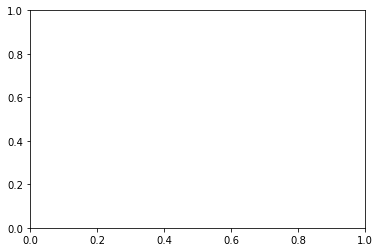

In [7]:
#Plots
#plots.plotFigure3b(epl.gammaCode)
plots.plotFigure3d(sMatrix)
plt.ylim([0,1])


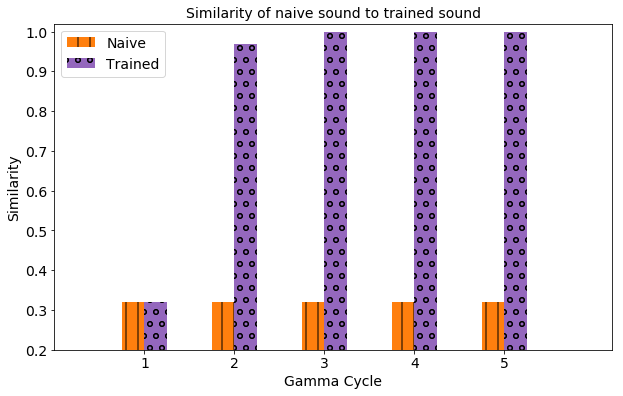

In [8]:
bar1_x, bar2_x = [], [];      
bar1_y, bar2_y = [], [];      
nGamma = 5; 
testOdorID = 0;              #sniff ID of test odor 
for i in range(0, nGamma):
    bar1_y.append(sMatrix[nGamma*testOdorID][0]);
    bar2_y.append(sMatrix[nGamma*testOdorID+i][0]);
w = 0.25        #width of bars
fsize = 14;
xticks = []
xtick_labels = []
for i in range(0, 5):    
    bar1_x.append(i-w/2);
    bar2_x.append(i+w/2);
    xticks.append(i)
    xtick_labels.append(str(i+1))
plt.figure(figsize=(10, 6))
fig = plt.subplot(111)
bar1 = plt.bar(bar1_x, bar1_y, width = w, color = 'tab:orange', align='center', hatch = "|")
bar2 = plt.bar(bar2_x, bar2_y, width = w, color = 'tab:purple', align='center', hatch = "o")
plt.xlim(-1, len(bar1_x)+0.2)
plt.ylim(0.2, 1.02)
plt.xticks(xticks, xtick_labels, fontsize=fsize)
plt.yticks(fontsize=fsize); 
fig.legend( (bar1, bar2), ('Naive', 'Trained'), loc = 'upper left', fontsize=fsize)
plt.ylabel('Similarity', fontsize=fsize); 
plt.xlabel('Gamma Cycle', fontsize=fsize);
plt.title("Similarity of naive sound to trained sound", fontsize=fsize); 
plt.show()